<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG012d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

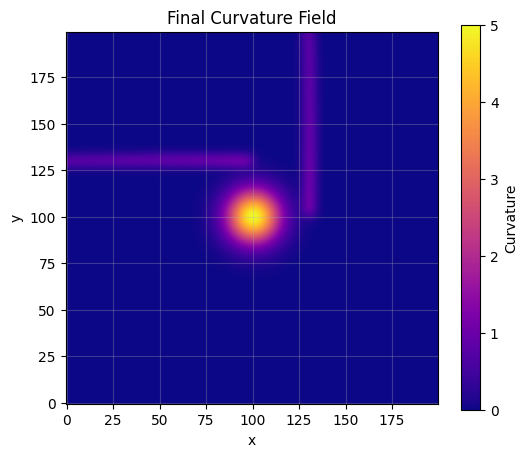

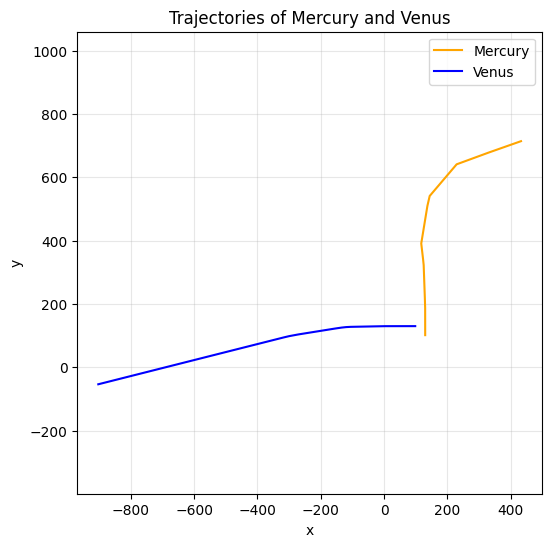

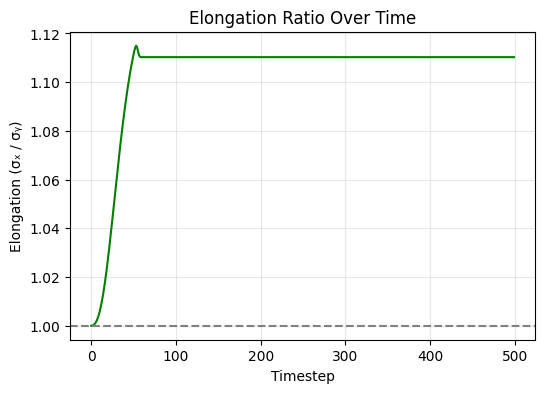

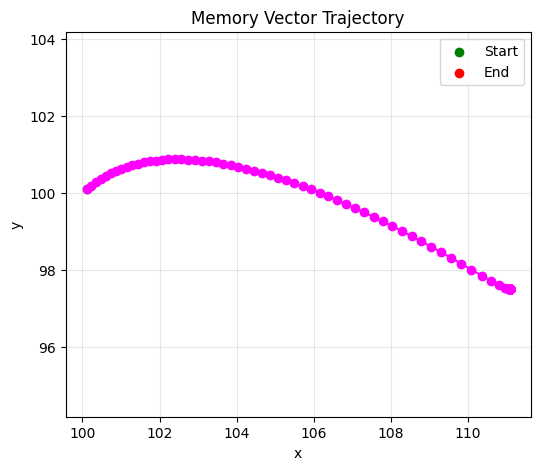

In [ ]:
# TEG012D — Repeated Perturbation Memory Fatigue
# Tests basin hysteresis and memory saturation from multiple orbital shocks

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

# === Parameters ===
grid_size = 200
timesteps = 500
A_sun = 5.0
sigma_sun = 10
A_body = 0.2
sigma_body = 3
perturb_steps = [150, 250, 350]
perturb_vector = np.array([0.5, -0.5])

# === Coordinate Grid ===
X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))

# === Initial Curvature Field ===
curvature = np.zeros((grid_size, grid_size))
dx_sun = X - 100
dy_sun = Y - 100
sun_field = A_sun * np.exp(-(dx_sun**2 + dy_sun**2) / (2 * sigma_sun**2))
curvature += sun_field

# === Initial Conditions ===
mercury_pos = np.array([130.0, 100.0])
mercury_vel = np.array([0.0, 1.5])
venus_pos = np.array([100.0, 130.0])
venus_vel = np.array([-1.5, 0.0])

mercury_traj = []
venus_traj = []
elongation_history = []
memory_vector = []

# === Weighted standard deviation ===
def weighted_std(values, weights):
    avg = np.average(values, weights=weights)
    var = np.average((values - avg)**2, weights=weights)
    return np.sqrt(var)

# === Simulation Loop ===
for t in range(timesteps):
    if t in perturb_steps:
        mercury_vel += perturb_vector

    grad_y, grad_x = np.gradient(curvature)

    # Mercury update
    fx_m = -grad_x[int(mercury_pos[1]) % grid_size, int(mercury_pos[0]) % grid_size]
    fy_m = -grad_y[int(mercury_pos[1]) % grid_size, int(mercury_pos[0]) % grid_size]
    mercury_vel += np.array([fx_m, fy_m]) * 0.1
    mercury_pos += mercury_vel
    mercury_traj.append(mercury_pos.copy())

    # Venus update
    fx_v = -grad_x[int(venus_pos[1]) % grid_size, int(venus_pos[0]) % grid_size]
    fy_v = -grad_y[int(venus_pos[1]) % grid_size, int(venus_pos[0]) % grid_size]
    venus_vel += np.array([fx_v, fy_v]) * 0.1
    venus_pos += venus_vel
    venus_traj.append(venus_pos.copy())

    # Curvature bumps
    for pos in [mercury_pos, venus_pos]:
        dx = X - pos[0]
        dy = Y - pos[1]
        bump = A_body * np.exp(-(dx**2 + dy**2) / (2 * sigma_body**2))
        curvature += bump

    # Elongation
    x_proj = np.sum(curvature, axis=0)
    y_proj = np.sum(curvature, axis=1)
    elong_x = weighted_std(np.arange(grid_size), x_proj)
    elong_y = weighted_std(np.arange(grid_size), y_proj)
    elongation_history.append(elong_x / (elong_y + 1e-8))

    # Memory vector
    com = center_of_mass(curvature)
    memory_vector.append(com)

# === Plot 1: Final Curvature Field ===
plt.figure(figsize=(6,5))
plt.imshow(curvature, cmap='plasma', origin='lower')
plt.colorbar(label='Curvature')
plt.title('Final Curvature Field')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3)
plt.show()

# === Plot 2: Trajectories ===
mercury_traj = np.array(mercury_traj)
venus_traj = np.array(venus_traj)
plt.figure(figsize=(6,6))
plt.plot(mercury_traj[:,0], mercury_traj[:,1], label='Mercury', color='orange')
plt.plot(venus_traj[:,0], venus_traj[:,1], label='Venus', color='blue')
plt.title('Trajectories of Mercury and Venus')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

# === Plot 3: Elongation Ratio Over Time ===
plt.figure(figsize=(6,4))
plt.plot(elongation_history, color='green')
plt.title('Elongation Ratio Over Time')
plt.xlabel('Timestep'); plt.ylabel('Elongation (σₓ / σᵧ)')
plt.grid(alpha=0.3)
plt.axhline(1.0, color='gray', linestyle='--')
plt.show()

# === Plot 4: Memory Vector Trajectory ===
memory_vector = np.array(memory_vector)
plt.figure(figsize=(6,5))
plt.plot(memory_vector[:,0], memory_vector[:,1], marker='o', color='magenta')
plt.title('Memory Vector Trajectory')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3)
plt.scatter(memory_vector[0,0], memory_vector[0,1], color='green', label='Start')
plt.scatter(memory_vector[-1,0], memory_vector[-1,1], color='red', label='End')
plt.legend()
plt.axis('equal')
plt.show()
